# 📊 Statistics — The Mathematical Foundation of Data Science
**Step 2: Data Science → Topic 08 → Class 24** | Date: February 18, 2024 🎯

> **Statistics helps us understand data and make evidence-based conclusions.**

```text
Data → Statistics → Patterns → Insights → Models → Decisions
```

## 🎯 Learning Objectives
Population/sample • parameter/statistic • data types & measurement levels • mean/median/mode • variance/std • percentiles/IQR/outliers • distributions & skewness • Z-score • probability & Bayes • sampling & bias • CLT • standard error • confidence intervals • hypothesis testing • p-value • Type I/II errors • correlation/covariance • NumPy/Pandas/SciPy statistics • visualization • statistics in ML

💡 **Use with YOUR data:** replace the sample dataset cell with `df = pd.read_csv("your_file.csv")`.

## 🧩 Mental Model
```text
                 STATISTICS
        ┌───────────┴───────────┐
   DESCRIPTIVE             INFERENTIAL
 "What does my data      "What can my sample tell
    look like?"           me about a population?"
 Mean/Median/Mode        Sampling / Estimation
 Variance / Std          Confidence Intervals
 Percentiles             Hypothesis Testing / p-values
```

## 🛠️ 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Setup complete ✅")

Setup complete ✅


## 👥 1. Population vs Sample | Parameter vs Statistic

| Population | Sample |
|---|---|
| Entire group | Subset |
| **Parameter** (μ, σ) | **Statistic** (x̄, s) |
| Usually unknown | Calculated from data |

```text
Population: 10,000 students → Sample: 500 students → Statistics → Estimate population
```

| Descriptive | Inferential |
|---|---|
| Describes existing data | Concludes about a population from a sample |
| Mean, median, std, percentiles | Confidence intervals, hypothesis tests, p-values |

In [2]:
# Demo: population parameter vs sample statistic
population = np.random.normal(loc=170, scale=10, size=100_000)   # heights of 100k people
sample = np.random.choice(population, size=500, replace=False)

print(f"Population mean (parameter μ): {population.mean():.2f}")
print(f"Sample mean     (statistic x̄): {sample.mean():.2f}")
# 🧠 The sample mean is close to (but not exactly) the population mean → that's why we need confidence intervals!

Population mean (parameter μ): 170.01
Sample mean     (statistic x̄): 169.83


## 📦 2. Data, Variables & Types of Data

| Type | Meaning | Examples |
|---|---|---|
| **Qualitative** | Categories | Gender, City, Department |
| **Quantitative** | Numbers | Age, Salary, Marks |
| **Discrete** | Countable | Number of orders |
| **Continuous** | Any value in a range | Height, weight, time |

### 📐 Levels of Measurement
| Level | Order? | Meaningful zero? | Example |
|---|---|---|---|
| Nominal | ❌ | ❌ | City, Blood group |
| Ordinal | ✅ | ❌ | Poor < Average < Good |
| Interval | ✅ | ❌ | Temperature °C |
| Ratio | ✅ | ✅ | Weight, Salary, Age |

In [3]:
# 📦 Sample dataset (Student Performance)
rng = np.random.default_rng(42)
n = 200
df = pd.DataFrame({
    "Student": [f"S{i}" for i in range(1, n + 1)],
    "Age": rng.integers(18, 26, n),
    "Department": rng.choice(["CS", "IT", "SE", "AI"], n),
    "Grade": rng.choice(["Poor", "Average", "Good", "Excellent"], n, p=[0.1, 0.4, 0.35, 0.15]),
    "Study_Hours": rng.uniform(0.5, 9, n).round(1),
    "Attendance": rng.integers(50, 100, n),
})
df["Marks"] = (25 + 6 * df["Study_Hours"] + 0.25 * df["Attendance"] + rng.normal(0, 5, n)).clip(0, 100).round()
df["Salary"] = rng.lognormal(10.8, 0.7, n).round(-2)     # right-skewed
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student      200 non-null    str    
 1   Age          200 non-null    int64  
 2   Department   200 non-null    str    
 3   Grade        200 non-null    str    
 4   Study_Hours  200 non-null    float64
 5   Attendance   200 non-null    int64  
 6   Marks        200 non-null    float64
 7   Salary       200 non-null    float64
dtypes: float64(3), int64(2), str(3)
memory usage: 12.6 KB


,Student,Age,Department,Grade,Study_Hours,Attendance,Marks,Salary
0,S1,18,IT,Good,3.1,93,60.0,51200.0
1,S2,24,AI,Excellent,8.3,73,97.0,13000.0
2,S3,23,IT,Good,7.1,99,94.0,12400.0
3,S4,21,SE,Average,1.4,88,67.0,48600.0
4,S5,21,IT,Poor,9.0,82,100.0,42000.0


In [4]:
# Identify variable types in code
print("Numerical  :", df.select_dtypes(include="number").columns.tolist())
print("Categorical:", df.select_dtypes(exclude="number").columns.tolist())

# Make an ordinal column properly ordered
df["Grade"] = pd.Categorical(df["Grade"], categories=["Poor", "Average", "Good", "Excellent"], ordered=True)
print(df["Grade"].min(), "<", df["Grade"].max())

Numerical  : ['Age', 'Study_Hours', 'Attendance', 'Marks', 'Salary']
Categorical: ['Student', 'Department', 'Grade']
Poor < Excellent


## 📊 3. Frequency & Frequency Distribution

In [5]:
marks_small = pd.Series([70, 80, 80, 90, 80, 70])
print(marks_small.value_counts().sort_index())

# Frequency table for a categorical column (counts + %)
freq = df["Department"].value_counts().to_frame("Frequency")
freq["Percent"] = (freq["Frequency"] / len(df) * 100).round(1)
freq

70    2
80    3
90    1
Name: count, dtype: int64


,Frequency,Percent
Department,,
IT,57,28.5
CS,51,25.5
AI,46,23.0
SE,46,23.0


## 🧮 4. Mean, Median, Mode

$$Mean = \frac{\sum x}{n}$$

| Measure | Meaning | Best for |
|---|---|---|
| Mean | Average | Balanced numeric data |
| Median | Middle value | Skewed data / outliers |
| Mode | Most common | Categories / repeated values |

⚠️ Mean is sensitive to outliers; median is resistant.

In [6]:
data = np.array([10, 20, 30])
print("Mean  :", np.mean(data))                   # (10+20+30)/3 = 20

print("Median (odd) :", np.median([10, 20, 30, 40, 50]))   # 30
print("Median (even):", np.median([10, 20, 30, 40]))       # (20+30)/2 = 25

m = stats.mode([10, 20, 20, 30, 40], keepdims=False)
print("Mode  :", m.mode, "| count:", m.count)

Mean  : 20.0
Median (odd) : 30.0
Median (even): 25.0
Mode  : 20 | count: 2


In [7]:
# ⚠️ Outlier effect: mean vs median
normal = np.array([10, 20, 30, 40, 50])
with_outlier = np.array([10, 20, 30, 40, 1000])
print(f"Without outlier → mean={normal.mean():.1f}, median={np.median(normal):.1f}")
print(f"With outlier    → mean={with_outlier.mean():.1f}, median={np.median(with_outlier):.1f}")
# 🧠 Mean jumps to 220, median stays 30 → report median for skewed data (e.g. salaries)

Without outlier → mean=30.0, median=30.0
With outlier    → mean=220.0, median=30.0


In [8]:
# Real dataset: Salary is right-skewed → mean > median
print(f"Salary mean  : {df['Salary'].mean():,.0f}")
print(f"Salary median: {df['Salary'].median():,.0f}")
print("Department mode:", df["Department"].mode()[0])

Salary mean  : 59,832
Salary median: 50,350
Department mode: IT


## ⚖️ 5. Weighted Mean
$$\bar{x}_w = \frac{\sum wx}{\sum w}$$
Used for GPA, grades, finance, performance scores.

In [9]:
scores = np.array([80, 70, 90])        # Assignment, Midterm, Final
weights = np.array([0.20, 0.30, 0.50])

print("Weighted mean :", np.average(scores, weights=weights))     # 16 + 21 + 45 = 82
print("Simple mean   :", scores.mean())

Weighted mean : 82.0
Simple mean   : 80.0


## 📏 6. Range, Variance & Standard Deviation

$$Range = Max - Min \qquad \sigma = \sqrt{Variance}$$

- **Variance** = average squared distance from the mean (units are squared)
- **Std deviation** = typical spread, in original units ✅ easier to interpret

### 🎯 Population vs Sample (`ddof`)
- `np.std(data)` → `ddof=0` → **population**
- `np.std(data, ddof=1)` → **sample** (Bessel's correction)
- ⚠️ Pandas `.std()` uses **ddof=1** by default; NumPy uses **ddof=0**!

In [10]:
low_spread = np.array([48, 49, 50, 51, 52])
high_spread = np.array([10, 30, 50, 70, 90])

for name, arr in [("Low spread ", low_spread), ("High spread", high_spread)]:
    print(f"{name} → mean={arr.mean():.0f} | range={np.ptp(arr)} | var={arr.var():.1f} | std={arr.std():.2f}")

Low spread  → mean=50 | range=4 | var=2.0 | std=1.41
High spread → mean=50 | range=80 | var=800.0 | std=28.28


In [11]:
data = np.array([10, 20, 30, 40, 50])
print("Population std (ddof=0):", round(np.std(data), 3))
print("Sample std     (ddof=1):", round(np.std(data, ddof=1), 3))
print("Pandas .std() default  :", round(pd.Series(data).std(), 3), "← same as ddof=1")

Population std (ddof=0): 14.142
Sample std     (ddof=1): 15.811
Pandas .std() default  : 15.811 ← same as ddof=1


## 📊 7. Percentiles, Quartiles, IQR & Five-Number Summary

```text
0%       25%       50%       75%       100%
│---------│---------│---------│---------│
          Q1        Q2        Q3
```
$$IQR = Q3 - Q1$$
**Outlier fences:** Lower = Q1 − 1.5·IQR | Upper = Q3 + 1.5·IQR

> An outlier is **not automatically an error** — it may be a rare customer, high-value transaction, or genuine behavior. Investigate first!

In [12]:
data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 300])

print("90th percentile:", np.percentile(data, 90))
q1, q2, q3 = np.percentile(data, [25, 50, 75])
iqr = q3 - q1
print(f"Q1={q1}, Median={q2}, Q3={q3}, IQR={iqr}")

# Five-number summary
print("Five-number summary:", [data.min(), q1, q2, q3, data.max()])

90th percentile: 110.99999999999993
Q1=32.5, Median=55.0, Q3=77.5, IQR=45.0
Five-number summary: [np.int64(10), np.float64(32.5), np.float64(55.0), np.float64(77.5), np.int64(300)]


In [13]:
# IQR outlier detection (reusable function)
def iqr_outliers(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    print(f"Fences → lower: {lower:,.1f} | upper: {upper:,.1f}")
    return series[(series < lower) | (series > upper)]

out = iqr_outliers(df["Salary"])
print(f"Potential salary outliers: {len(out)} of {len(df)}")

Fences → lower: -24,775.0 | upper: 129,825.0
Potential salary outliers: 14 of 200


## 📈 8. Distributions & Normal Distribution 🔔

Normal: bell-shaped, symmetric, **mean ≈ median ≈ mode**.

### 📏 Empirical Rule (68–95–99.7)
```text
~68%   within 1σ
~95%   within 2σ
~99.7% within 3σ
```

Within 1σ: 68.3%
Within 2σ: 95.4%
Within 3σ: 99.7%


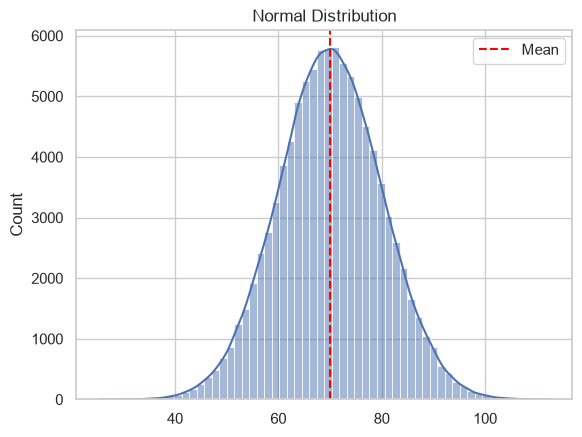

In [14]:
normal_data = np.random.normal(loc=70, scale=10, size=100_000)

for k in [1, 2, 3]:
    pct = np.mean(np.abs(normal_data - 70) <= k * 10) * 100
    print(f"Within {k}σ: {pct:.1f}%")

sns.histplot(normal_data, kde=True, bins=60)
plt.axvline(70, color="red", ls="--", label="Mean")
plt.title("Normal Distribution"); plt.legend(); plt.show()

## 📉 9. Skewness & Kurtosis

| Distribution | Typical relationship |
|---|---|
| Symmetric | Mean ≈ Median |
| Right-skewed (e.g. salary) | Mean > Median |
| Left-skewed (e.g. very easy exam) | Mean < Median |

**Kurtosis** = tail behavior (how often extreme values occur vs a normal reference) — *not* "how tall the graph is".

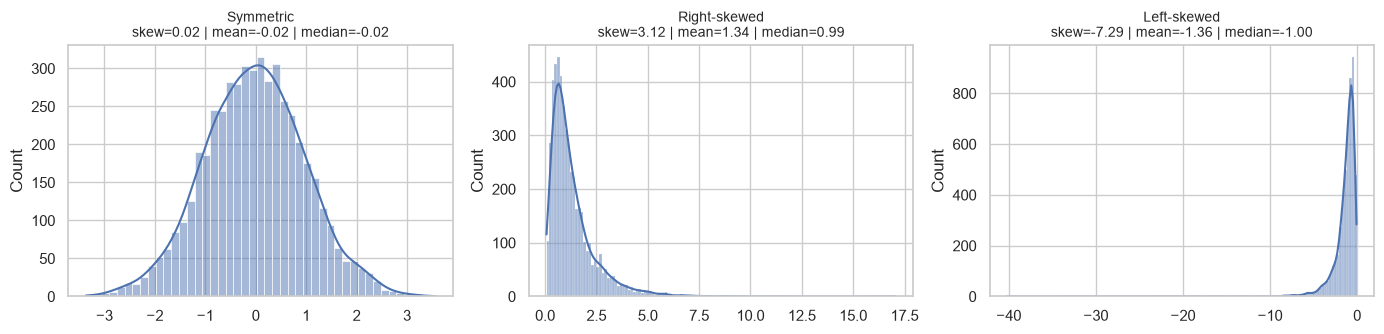

Excess kurtosis (normal ≈ 0): 0.03
Excess kurtosis (lognormal) : 18.96 ← heavy tail


In [15]:
right = np.random.lognormal(0, 0.8, 5000)
left = -np.random.lognormal(0, 0.8, 5000)
sym = np.random.normal(0, 1, 5000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, arr, title in zip(axes, [sym, right, left], ["Symmetric", "Right-skewed", "Left-skewed"]):
    sns.histplot(arr, kde=True, ax=ax)
    ax.set_title(f"{title}\nskew={stats.skew(arr):.2f} | mean={arr.mean():.2f} | median={np.median(arr):.2f}", fontsize=10)
plt.tight_layout(); plt.show()

print("Excess kurtosis (normal ≈ 0):", round(stats.kurtosis(sym), 2))
print("Excess kurtosis (lognormal) :", round(stats.kurtosis(right), 2), "← heavy tail")

## 🎯 10. Z-Score
$$z = \frac{x-\mu}{\sigma}$$
Example: mean=70, σ=10, score=90 → z=2 → **2 standard deviations above the mean**.

Rule of thumb: |z| > 3 = unusual. ⚠️ Don't blindly delete — investigate!

In [16]:
z = (90 - 70) / 10
print("z-score:", z)

# Z-scores for a real column
df["Marks_Z"] = stats.zscore(df["Marks"])
print(df.loc[df["Marks_Z"].abs() > 2, ["Student", "Marks", "Marks_Z"]].round(2))
print("Values with |z| > 3:", (df["Marks_Z"].abs() > 3).sum())

z-score: 2.0
   Student  Marks  Marks_Z
23     S24   39.0    -2.05
50     S51   38.0    -2.11
Values with |z| > 3: 0


## 🎲 11. Probability

$$P(A)=\frac{Favorable}{Total} \qquad P(A^c)=1-P(A)$$

- **Independent:** $P(A \cap B)=P(A)P(B)$ (two coin tosses)
- **Dependent:** one event affects the other (cards without replacement)
- **Conditional:** $P(A|B)=\frac{P(A\cap B)}{P(B)}$ (buy given visited product page)

In [17]:
# Simulate a fair die: P(6) should be ≈ 1/6
rolls = np.random.randint(1, 7, 100_000)
print(f"P(6) simulated = {np.mean(rolls == 6):.4f} | theory = {1/6:.4f}")

# Independent events: two heads in a row → 0.5 × 0.5 = 0.25
tosses = np.random.randint(0, 2, (100_000, 2))
print(f"P(HH) simulated = {np.mean(tosses.sum(axis=1) == 2):.4f} | theory = 0.25")

P(6) simulated = 0.1655 | theory = 0.1667
P(HH) simulated = 0.2487 | theory = 0.25


In [18]:
# Conditional probability from data: P(Marks ≥ 75 | Attendance ≥ 80)
high_att = df["Attendance"] >= 80
high_marks = df["Marks"] >= 75

p_a_and_b = (high_att & high_marks).mean()
p_b = high_att.mean()
print(f"P(High marks | High attendance) = {p_a_and_b / p_b:.3f}")
print(f"P(High marks)                   = {high_marks.mean():.3f}   ← compare!")

P(High marks | High attendance) = 0.534
P(High marks)                   = 0.430   ← compare!


## 🧮 12. Bayes' Theorem
$$P(A|B)=\frac{P(B|A)P(A)}{P(B)}$$
```text
Prior belief → New evidence → Updated belief
```
Used in spam filtering, medical diagnosis, classification (Naive Bayes), risk analysis.

In [19]:
# 🏥 Classic example: rare disease test
p_disease = 0.01            # 1% of people have the disease (prior)
sensitivity = 0.95          # P(positive | disease)
false_positive = 0.05       # P(positive | no disease)

p_positive = sensitivity * p_disease + false_positive * (1 - p_disease)
p_disease_given_pos = sensitivity * p_disease / p_positive
print(f"P(disease | positive test) = {p_disease_given_pos:.3f}")
# 🧠 Only ~16%! Even with a 95% accurate test, the low base rate matters. Classic interview question.

P(disease | positive test) = 0.161


## 👥 13. Sampling Methods & Bias

| Method | Idea |
|---|---|
| Simple random | Everyone has a chance |
| Systematic | Every k-th observation |
| Stratified | Sample within each group |
| Cluster | Select whole clusters |

⚠️ **Sampling bias:** the sample doesn't represent the population (e.g. asking only CS students about the whole university).
```text
Bad sample → Biased data → Misleading statistics → Bad conclusion
```

In [20]:
# Simple random
simple = df.sample(n=40, random_state=1)

# Systematic (every 5th row)
systematic = df.iloc[::5]

# Stratified by Department (20% from each group)
stratified = df.groupby("Department", group_keys=False).apply(lambda g: g.sample(frac=0.2, random_state=1))

# Cluster (pick 2 random departments entirely)
chosen = np.random.choice(df["Department"].unique(), 2, replace=False)
cluster = df[df["Department"].isin(chosen)]

print("Population Marks mean:", round(df["Marks"].mean(), 2))
for name, s in [("Simple", simple), ("Systematic", systematic), ("Stratified", stratified), ("Cluster", cluster)]:
    print(f"{name:11s} n={len(s):3d} → mean={s['Marks'].mean():.2f}")

Population Marks mean: 72.17
Simple      n= 40 → mean=76.42
Systematic  n= 40 → mean=71.58
Stratified  n= 39 → mean=74.95
Cluster     n=103 → mean=72.77


In [21]:
# ⚠️ Biased sample demo: only top-attendance students
biased = df[df["Attendance"] > 90]
print(f"True mean marks : {df['Marks'].mean():.2f}")
print(f"Biased sample   : {biased['Marks'].mean():.2f}  (n={len(biased)}) ← misleading!")

True mean marks : 72.17
Biased sample   : 77.42  (n=43) ← misleading!


## 📊 14. Central Limit Theorem (CLT)

> With sufficiently large random samples, the distribution of **sample means** becomes approximately normal — even if the population is not.

```text
Population → many samples → mean of each → distribution of means ≈ Normal
```

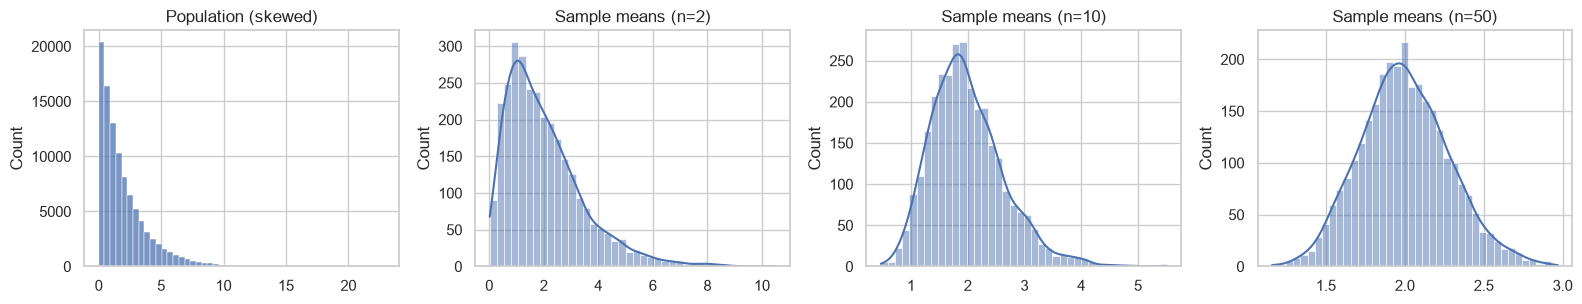

In [22]:
skewed_pop = np.random.exponential(scale=2, size=100_000)     # NOT normal

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
sns.histplot(skewed_pop, bins=50, ax=axes[0]).set_title("Population (skewed)")

for ax, size in zip(axes[1:], [2, 10, 50]):
    means = [np.random.choice(skewed_pop, size).mean() for _ in range(3000)]
    sns.histplot(means, bins=40, kde=True, ax=ax).set_title(f"Sample means (n={size})")
plt.tight_layout(); plt.show()
# 🧠 As n grows, the distribution of means becomes bell-shaped.

## 📐 15. Standard Error
$$SE = \frac{s}{\sqrt{n}}$$
Larger n → smaller SE → more precise estimate.

In [23]:
s = df["Marks"].std(ddof=1)
for n_ in [10, 50, 200, 1000]:
    print(f"n={n_:4d} → SE = {s / np.sqrt(n_):.3f}")

print("scipy sem on data:", round(stats.sem(df["Marks"]), 3))

n=  10 → SE = 5.134
n=  50 → SE = 2.296
n= 200 → SE = 1.148
n=1000 → SE = 0.513
scipy sem on data: 1.148


## 🎯 16. Confidence Interval

Range of plausible values for a population parameter. Example: average salary 80,000, 95% CI = [76,000, 84,000].

⚠️ **Correct interpretation:** if we repeated the procedure many times, ~95% of the intervals would contain the true parameter. It is *not* "95% probability the true value is in this one interval".

In [24]:
x = df["Marks"]
mean, se = x.mean(), stats.sem(x)

ci = stats.t.interval(0.95, df=len(x) - 1, loc=mean, scale=se)
print(f"Mean marks = {mean:.2f}")
print(f"95% CI     = ({ci[0]:.2f}, {ci[1]:.2f})")

Mean marks = 72.17
95% CI     = (69.90, 74.43)


In [25]:
# 🔬 Verify the meaning of "95%" by simulation
true_mean = 170
pop = np.random.normal(true_mean, 10, 200_000)
hits = 0
trials = 1000
for _ in range(trials):
    smp = np.random.choice(pop, 50)
    lo, hi = stats.t.interval(0.95, df=49, loc=smp.mean(), scale=stats.sem(smp))
    hits += lo <= true_mean <= hi
print(f"{hits / trials:.1%} of the intervals contained the true mean")

95.7% of the intervals contained the true mean


## 🧪 17. Hypothesis Testing

```text
Question → H₀ & Hₐ → Sample → Choose test → Test statistic → p-value → Compare with α → Conclusion
```
- **H₀** (null): baseline claim, e.g. μ = 30
- **Hₐ** (alternative): e.g. μ ≠ 30
- **α** (significance level): chosen **before** testing, usually 0.05
- **p-value** < α → evidence against H₀ | p-value ≥ α → insufficient evidence to reject H₀

⚠️ p-value is **NOT** the probability that H₀ is true.
🚨 Statistical significance ≠ practical significance.

In [26]:
# 🚚 One-sample t-test: company claims average delivery = 30 minutes
delivery = np.random.normal(loc=33, scale=8, size=60)     # actual data

t_stat, p = stats.ttest_1samp(delivery, popmean=30)
alpha = 0.05
print("H₀: μ = 30   |   Hₐ: μ ≠ 30")
print(f"t = {t_stat:.3f}, p-value = {p:.4f}")
print("Conclusion:", "Reject H₀ (evidence mean ≠ 30)" if p < alpha else "Fail to reject H₀ (insufficient evidence)")

H₀: μ = 30   |   Hₐ: μ ≠ 30
t = 3.722, p-value = 0.0004
Conclusion: Reject H₀ (evidence mean ≠ 30)


In [27]:
# 🆚 Two-sample t-test: do CS students score differently than IT students?
cs = df.loc[df["Department"] == "CS", "Marks"]
it = df.loc[df["Department"] == "IT", "Marks"]

t_stat, p = stats.ttest_ind(cs, it, equal_var=False)      # Welch's t-test (safer default)
print(f"CS mean={cs.mean():.1f} | IT mean={it.mean():.1f}")
print(f"t={t_stat:.3f}, p={p:.4f} →", "significant" if p < 0.05 else "no significant difference")

CS mean=72.0 | IT mean=73.9
t=-0.615, p=0.5399 → no significant difference


In [28]:
# 🔗 Chi-square test of independence (two categorical variables)
table = pd.crosstab(df["Department"], df["Grade"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(table)
print(f"\nchi2={chi2:.2f}, dof={dof}, p={p:.4f}")

Grade       Poor  Average  Good  Excellent
Department                                
AI             3       16    15         12
CS             5       23    16          7
IT             6       24    21          6
SE             2       19    22          3

chi2=11.48, dof=9, p=0.2442


Marks   p=0.0000 → NOT normal
Salary  p=0.0000 → NOT normal


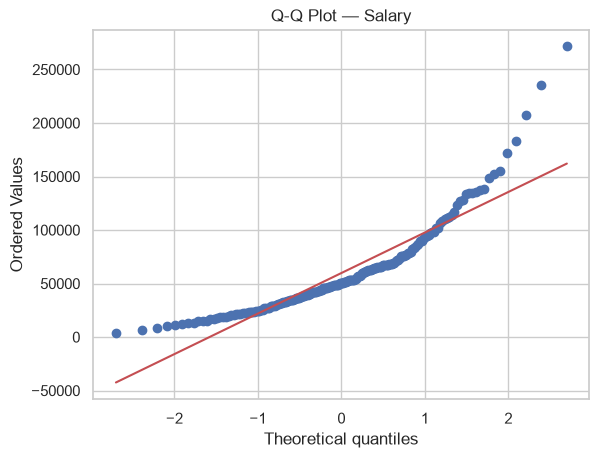

In [29]:
# 🔔 Normality test (H₀: data is normal)
for col in ["Marks", "Salary"]:
    stat, p = stats.normaltest(df[col])
    print(f"{col:7s} p={p:.4f} →", "looks normal" if p >= 0.05 else "NOT normal")

stats.probplot(df["Salary"], dist="norm", plot=plt)     # Q-Q plot
plt.title("Q-Q Plot — Salary"); plt.show()

## ❌ 18. Type I & Type II Errors

|  | Reality: H₀ True | Reality: H₀ False |
|---|---|---|
| **Reject H₀** | ❌ Type I (false positive) | ✅ Correct |
| **Don't reject H₀** | ✅ Correct | ❌ Type II (false negative) |

In [30]:
# 🔬 Simulate Type I error: both groups come from the SAME distribution, H₀ is TRUE
false_positives = 0
trials = 2000
for _ in range(trials):
    a, b = np.random.normal(50, 10, 30), np.random.normal(50, 10, 30)
    if stats.ttest_ind(a, b).pvalue < 0.05:
        false_positives += 1
print(f"Type I error rate ≈ {false_positives / trials:.3f}  (should be ≈ α = 0.05)")

# Type II: a REAL difference exists (mean 50 vs 55) but we sometimes miss it
misses = 0
for _ in range(trials):
    a, b = np.random.normal(50, 10, 30), np.random.normal(55, 10, 30)
    if stats.ttest_ind(a, b).pvalue >= 0.05:
        misses += 1
print(f"Type II error rate ≈ {misses / trials:.3f}  → power ≈ {1 - misses / trials:.2f}")

Type I error rate ≈ 0.048  (should be ≈ α = 0.05)
Type II error rate ≈ 0.518  → power ≈ 0.48


## 🔗 19. Correlation & Covariance

**Pearson r** ranges from −1 to +1.

| r | Interpretation |
|---|---|
| +1 | Perfect positive linear |
| 0 | No **linear** correlation (could still be nonlinear!) |
| −1 | Perfect negative linear |

| Covariance | Correlation |
|---|---|
| Joint variation | Standardized linear association |
| Unit-dependent | Unitless |
| Any scale | Always −1 to +1 |

In [31]:
print("Covariance matrix:\n", df[["Study_Hours", "Marks"]].cov().round(2))
print("\nCorrelation matrix:\n", df[["Study_Hours", "Marks"]].corr().round(3))

r, p = stats.pearsonr(df["Study_Hours"], df["Marks"])
print(f"\nPearson r = {r:.3f}, p-value = {p:.2e}")

Covariance matrix:
              Study_Hours   Marks
Study_Hours         6.16   37.06
Marks              37.06  263.59

Correlation matrix:
              Study_Hours  Marks
Study_Hours         1.00   0.92
Marks               0.92   1.00

Pearson r = 0.920, p-value = 1.85e-82


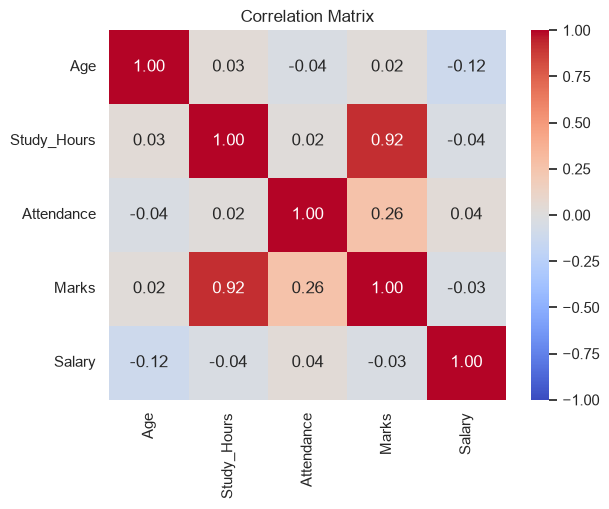

In [32]:
# Correlation matrix heatmap
corr = df[["Age", "Study_Hours", "Attendance", "Marks", "Salary"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix"); plt.show()

In [33]:
# ⚠️ Correlation ≠ Causation + nonlinear blind spot
x = np.linspace(-3, 3, 200)
y = x ** 2                                            # perfect relationship, but NOT linear
print("Pearson r for y = x²:", round(np.corrcoef(x, y)[0, 1], 3), "← r ≈ 0 despite perfect dependence!")

# Confounder demo: temperature drives BOTH ice cream sales and sunburn
temp = np.random.normal(30, 5, 500)
ice_cream = 10 * temp + np.random.normal(0, 20, 500)
sunburn = 2 * temp + np.random.normal(0, 5, 500)
print("Ice cream vs sunburn r:", round(np.corrcoef(ice_cream, sunburn)[0, 1], 3), "← both caused by hot weather (Z → X and Y)")

Pearson r for y = x²: -0.0 ← r ≈ 0 despite perfect dependence!
Ice cream vs sunburn r: 0.849 ← both caused by hot weather (Z → X and Y)


## 🐍 20. Statistics with NumPy, Pandas & SciPy

| Library | Role |
|---|---|
| NumPy | Numerical statistics |
| Pandas | DataFrame statistics |
| SciPy | Tests & advanced statistics |
| Matplotlib / Seaborn | Visualization |

In [34]:
arr = np.array([10, 20, 30, 40, 50])
print("NumPy →", np.mean(arr), np.median(arr), np.min(arr), np.max(arr),
      round(np.std(arr), 2), np.var(arr), np.percentile(arr, 75))

NumPy → 30.0 30.0 10 50 14.14 200.0 40.0


In [35]:
print("Pandas describe():")
df[["Study_Hours", "Attendance", "Marks", "Salary"]].describe().round(2)

Pandas describe():


,Study_Hours,Attendance,Marks,Salary
count,200.00,200.00,200.00,200.00
mean,4.70,76.14,72.17,59832.00
std,2.48,14.57,16.24,40814.32
min,0.50,50.00,38.00,3800.00
25%,2.48,64.00,60.00,33200.00
50%,4.80,76.00,71.50,50350.00
75%,6.80,88.00,86.00,71850.00
max,9.00,99.00,100.00,271500.00


In [36]:
# SciPy summary
stats.describe(df["Marks"])

DescribeResult(nobs=np.int64(200), minmax=(np.float64(38.0), np.float64(100.0)), mean=np.float64(72.165), variance=np.float64(263.58570351758794), skewness=np.float64(-0.06034172502372623), kurtosis=np.float64(-0.9881779280537524))

## 📈 21. Statistical Visualization
| Plot | Useful for |
|---|---|
| Histogram / KDE | Distribution |
| Box plot | Spread & outliers |
| Scatter | Relationships |
| Heatmap | Correlation matrix |
| Q-Q plot | Normality |

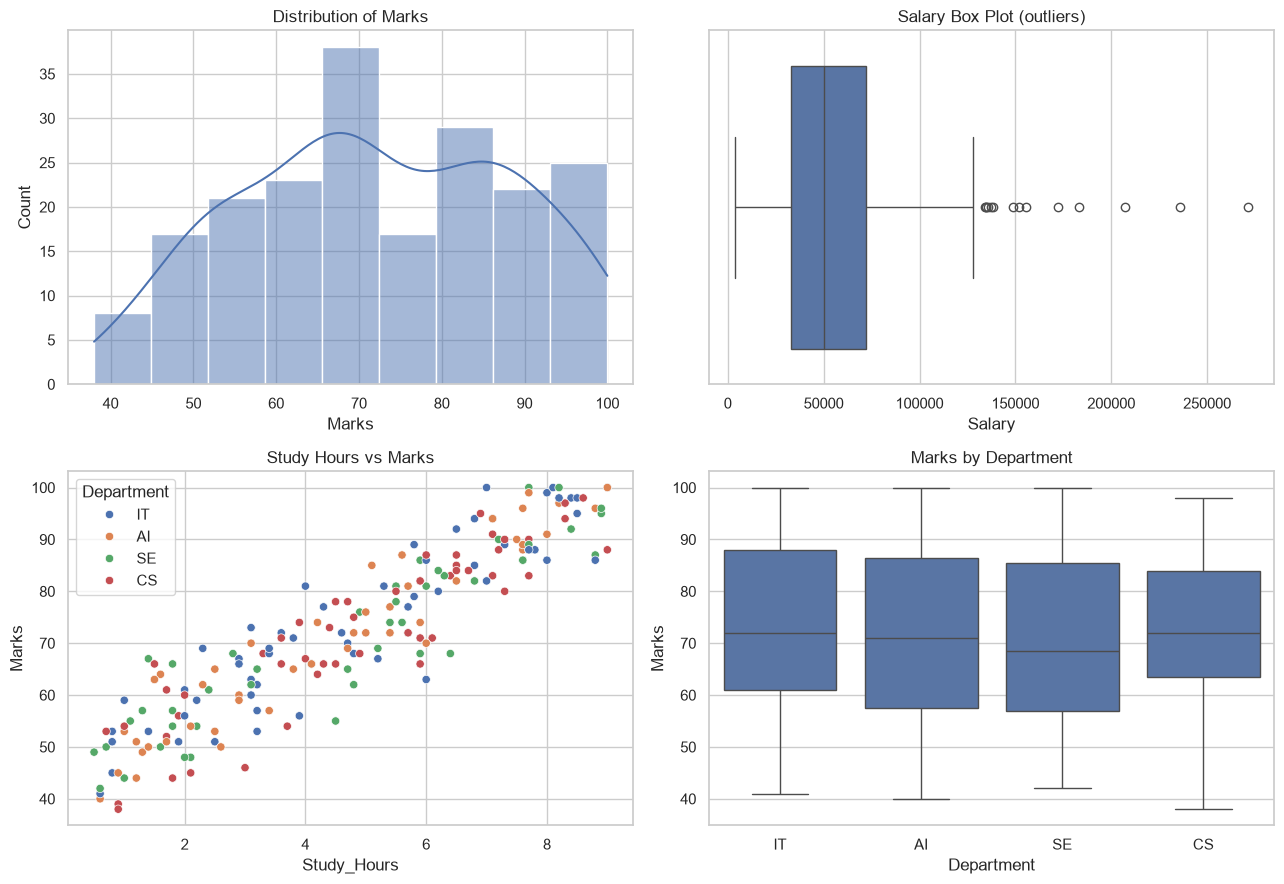

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["Marks"], kde=True, ax=axes[0, 0]).set_title("Distribution of Marks")
sns.boxplot(x=df["Salary"], ax=axes[0, 1]).set_title("Salary Box Plot (outliers)")
sns.scatterplot(data=df, x="Study_Hours", y="Marks", hue="Department", ax=axes[1, 0]).set_title("Study Hours vs Marks")
sns.boxplot(data=df, x="Department", y="Marks", ax=axes[1, 1]).set_title("Marks by Department")

plt.tight_layout(); plt.show()

## 🤖 22. Statistics in Machine Learning

| Stage | Statistics used |
|---|---|
| Data understanding | Mean, median, distribution, variance |
| Data cleaning | Missing values, outliers |
| Feature engineering | Scaling, transformation, correlation |
| Feature selection | Correlation, variance, significance |
| Model evaluation | Error distributions, CI, statistical tests |
| AI | Probability, Bayesian inference, sampling, uncertainty |

```text
ML → Probability + Statistics → Deep Learning → Generative AI → LLMs
```

## ⚠️ 23. Common Statistical Mistakes ❌
1. Using the mean for everything (skewed data → use median)
2. Automatically removing outliers
3. Correlation = causation
4. Misinterpreting the p-value
5. Ignoring sample bias (big biased sample is still biased)
6. Confusing population and sample (`ddof`)
7. Using tests without checking assumptions (independence, distribution, variance)

## 🧠 Questions to Ask About Any Dataset
| Aspect | Question |
|---|---|
| Center | What's the typical value? |
| Spread | How much do values vary? |
| Shape | Symmetric or skewed? |
| Outliers | Any unusual observations? |
| Relationship | How are variables related? |
| Uncertainty | How confident are we? |
| Population | Does the sample represent it? |

## 🧮 24. Formula Sheet

| Concept | Formula |
|---|---|
| Mean | $\bar{x} = \frac{\sum x}{n}$ |
| Weighted mean | $\frac{\sum wx}{\sum w}$ |
| Range | $Max - Min$ |
| Population variance | $\frac{\sum(x-\mu)^2}{N}$ |
| Std deviation | $\sigma = \sqrt{Variance}$ |
| IQR | $Q3 - Q1$ |
| Z-score | $\frac{x-\mu}{\sigma}$ |
| Standard error | $\frac{s}{\sqrt{n}}$ |
| Probability | $\frac{Favorable}{Total}$ |
| Conditional | $\frac{P(A\cap B)}{P(B)}$ |
| Bayes | $\frac{P(B|A)P(A)}{P(B)}$ |

## 🧠 What to MEMORIZE vs REFERENCE
| 🧠 Memorize | 📖 Reference |
|---|---|
| Mean vs median (when to use) | Exact SciPy function names |
| ddof=0 vs ddof=1 | Formula details |
| p-value meaning (and what it is NOT) | Test-selection tables |
| Type I vs Type II | CI formula variants |
| Correlation ≠ causation | Plot styling |
| CLT idea, Bayes idea | Distribution parameter names |

## 🔬 25. Complete Statistical Analysis Workflow
```text
1 Understand problem → 2 Population/sample → 3 Variables → 4 Variable types → 5 Data quality
→ 6 Descriptive stats → 7 Distributions → 8 Outliers → 9 Relationships → 10 Statistical methods
→ 11 Quantify uncertainty → 12 Interpret → 13 Communicate
```

### 🧠 Question-Driven Statistics
| Question | Tools |
|---|---|
| Typical order value? | Mean, median, distribution |
| Highly variable? | Std, IQR, histogram, box plot |
| Age and spending related? | Scatter, correlation |
| Avg delivery ≠ target? | Hypothesis test, CI |

```text
QUESTION → DATA → STATISTIC → VISUALIZATION → INTERPRETATION → INSIGHT
```

## 🧪 26. Mini Project — Student Performance Statistical Analysis
Steps: load → inspect → calculate (mean/median/mode/range/var/std/percentiles/IQR) → analyze distributions → detect outliers → relationships → visualize → **write insights**.

> Replace `df` below with your own CSV. The important part is not the numbers — it's **explaining what they mean**.

In [38]:
# Step 1-2: Load + inspect (df already loaded above; use pd.read_csv("student_data.csv") for your own)
print(df.shape)
print(df.isna().sum().sum(), "missing values")

# Step 3: Descriptive statistics
cols = ["Study_Hours", "Attendance", "Marks"]
summary = pd.DataFrame({
    "mean": df[cols].mean(),
    "median": df[cols].median(),
    "std": df[cols].std(),
    "range": df[cols].max() - df[cols].min(),
    "Q1": df[cols].quantile(0.25),
    "Q3": df[cols].quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(2)

(200, 9)
0 missing values


,mean,median,std,range,Q1,Q3,IQR
Study_Hours,4.70,4.8,2.48,8.5,2.48,6.8,4.32
Attendance,76.14,76.0,14.57,49.0,64.00,88.0,24.00
Marks,72.17,71.5,16.24,62.0,60.00,86.0,26.00


In [39]:
# Step 4-6: Distribution, outliers, relationships
print("Marks skewness:", round(df["Marks"].skew(), 2))
print("Marks outliers (IQR):", len(iqr_outliers(df["Marks"])))
print("\nCorrelation with Marks:")
print(df[["Study_Hours", "Attendance"]].corrwith(df["Marks"]).round(3))

Marks skewness: -0.06
Fences → lower: 21.0 | upper: 125.0
Marks outliers (IQR): 0

Correlation with Marks:
Study_Hours    0.920
Attendance     0.263
dtype: float64


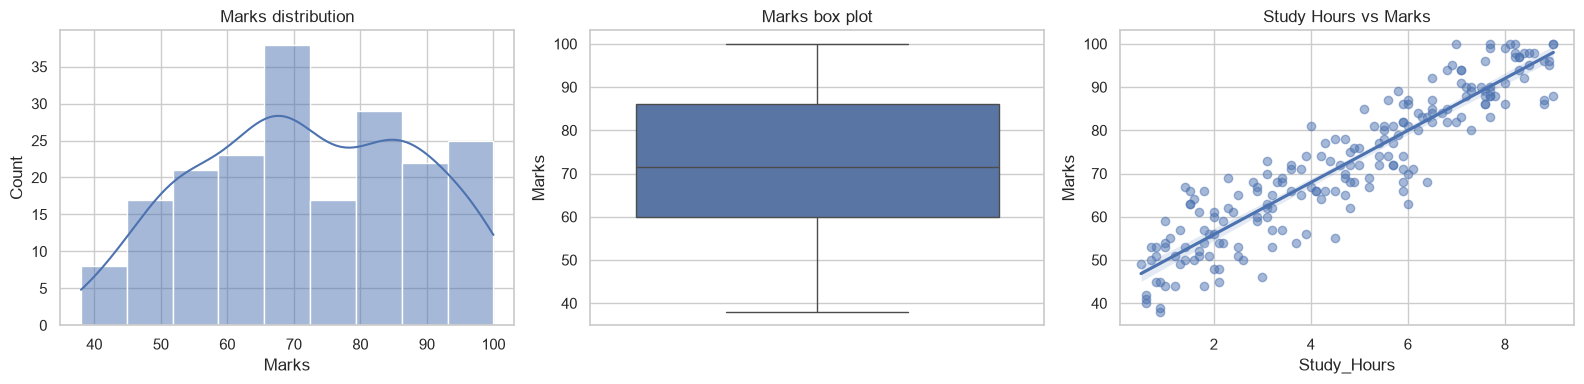

In [40]:
# Step 7: Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Marks"], kde=True, ax=axes[0]).set_title("Marks distribution")
sns.boxplot(y=df["Marks"], ax=axes[1]).set_title("Marks box plot")
sns.regplot(data=df, x="Study_Hours", y="Marks", ax=axes[2], scatter_kws={"alpha": 0.5}).set_title("Study Hours vs Marks")
plt.tight_layout(); plt.show()

In [41]:
# Step 8: Auto-generate written insights
r_study = df["Study_Hours"].corr(df["Marks"])
r_att = df["Attendance"].corr(df["Marks"])
ci = stats.t.interval(0.95, len(df) - 1, loc=df["Marks"].mean(), scale=stats.sem(df["Marks"]))

print(f"Insight 1: The median marks were {df['Marks'].median():.0f} (mean {df['Marks'].mean():.1f}).")
print(f"Insight 2: Marks distribution skewness is {df['Marks'].skew():.2f} → {'roughly symmetric' if abs(df['Marks'].skew()) < 0.5 else 'noticeably skewed'}.")
print(f"Insight 3: Study hours show a {'strong' if abs(r_study) > 0.6 else 'moderate/weak'} positive linear association with marks (r={r_study:.2f}).")
print(f"Insight 4: Attendance vs marks r={r_att:.2f}. Correlation alone does not prove causation.")
print(f"Insight 5: We are 95% confident (CI method) that the population mean marks lie between {ci[0]:.1f} and {ci[1]:.1f}.")

Insight 1: The median marks were 72 (mean 72.2).
Insight 2: Marks distribution skewness is -0.06 → roughly symmetric.
Insight 3: Study hours show a strong positive linear association with marks (r=0.92).
Insight 4: Attendance vs marks r=0.26. Correlation alone does not prove causation.
Insight 5: We are 95% confident (CI method) that the population mean marks lie between 69.9 and 74.4.


## ✏️ 27. Practice Exercises

**Beginner**
1. `data = [10, 20, 30, 40, 50]` → mean, median, mode, range, variance, std
2. `10, 20, 20, 30, 40, 50` → mean, median, mode
3. Calculate Q1, median, Q3, IQR

**Intermediate**
4. Create a student dataset → mean, median, std of marks
5. Find outliers with the IQR method
6. Covariance & correlation of Study Hours vs Marks
7. Correlation matrix with Pandas + Seaborn heatmap

**Advanced**
8. Generate normal data with NumPy → analyze mean/median/std/distribution
9. Compare the means of Group A vs Group B statistically
10. Run a suitable SciPy hypothesis test and explain H₀, Hₐ, α, test statistic, p-value, conclusion

In [42]:
# ✏️ Your practice space — Exercise 1
data = [10, 20, 30, 40, 50]
# TODO: calculate mean, median, mode, range, variance, std

## 🎯 28. Key Takeaways
- **Descriptive** describes the data we have; **Inferential** concludes about a population from a sample
- **Mean** = average | **Median** = middle | **Mode** = most frequent
- **Std** = spread around the mean | **IQR** = spread of the middle 50%
- **Z-score** = distance from the mean in SD units
- **CLT** → sample means tend toward normal | **SE** shrinks as n grows
- **CI** = plausible range for a parameter | **p-value** = evidence under H₀ (not P(H₀ true))
- ⭐ **Correlation does not automatically mean causation**

> **NumPy** = numerical tools • **Pandas** = data tools • **Matplotlib/Seaborn** = visualization • **Statistics** = the reasoning layer between raw data and ML

## ❓ 29. Interview Questions
**Beginner:** 1 What is Statistics? 2 Why important in Data Science? 3 Population vs sample? 4 Parameter? 5 Statistic? 6 Mean? 7 Median? 8 Mode? 9 Range? 10 Variance? 11 Std deviation? 12 Percentile? 13 Quartiles? 14 IQR? 15 Outlier?

**Intermediate:** 16 Mean vs median? 17 Why is median resistant to outliers? 18 Skewness? 19 Normal distribution? 20 Z-score? 21 Probability? 22 Conditional probability? 23 Sampling? 24 Sampling bias? 25 CLT? 26 Standard error? 27 Confidence interval? 28 Hypothesis testing? 29 Null hypothesis? 30 Alternative hypothesis? 31 p-value? 32 Significance level? 33 Type I error? 34 Type II error? 35 Correlation?

**Advanced:** 36 Correlation vs covariance? 37 Correlation vs causation? 38 Mean vs median — when? 39 How to detect outliers? 40 What is CLT used for? 41 Why does SE fall as n grows? 42 What does a 95% CI mean? 43 Why isn't p-value P(H₀ true)? 44 Test assumptions? 45 Statistical significance? 46 Statistical vs practical significance? 47 Sampling bias? 48 Selection bias? 49 Correlation matrix? 50 Statistics in ML?

### 💼 Model Answers
- **Mean vs Median:** Mean is the arithmetic average; median is the middle value after sorting and is less affected by extreme values.
- **Std deviation:** Measures how spread out observations are around the mean.
- **p-value:** How surprising the observed result (or more extreme) would be if H₀ were true, under the test's assumptions.
- **Correlation vs causation:** Correlation describes association; it doesn't by itself show one variable causes the other.
- **Population vs sample:** Population = complete group of interest; sample = subset selected from it.

## 🗺️ Roadmap
```text
17 NumPy → 18 Pandas → 19 Matplotlib → 20 Seaborn → 21 Data Cleaning → 22 EDA → 23 Feature Engineering → 24 Statistics → 25 Machine Learning
```